In [1]:
import pandas as pd

data=pd.read_csv("cardio_train (1).csv")
data=data.dropna()
headers=data.columns
data.drop(columns=['id'],inplace=True)
display(data)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,PP,MAP,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,30,90.000000,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,50,106.666667,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,60,90.000000,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,50,116.666667,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,40,73.333333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,40,93.333333,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,50,106.666667,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,90,120.000000,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,55,98.333333,1


In [2]:
data_lof = data.copy(deep=True)
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20,contamination=0.20)
outlier_scores = lof.fit_predict(data_lof)

data_lof["LOF_Score"] = outlier_scores
data_lof = data_lof[data_lof["LOF_Score"]>=0]
data_lof.drop(columns=['LOF_Score'],inplace=True)
display(data_lof)
data3=data_lof.copy(deep=True)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,PP,MAP,cardio
1,20228,1,156,85.0,140,90,3,1,0,0,1,50,106.666667,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,60,90.000000,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,50,116.666667,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,40,73.333333,0
5,21914,1,151,67.0,120,80,2,2,0,0,0,40,93.333333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,19699,1,172,70.0,130,90,1,1,0,0,1,40,103.333333,1
69994,21074,1,165,80.0,150,80,1,1,0,0,1,70,103.333333,1
69995,19240,2,168,76.0,120,80,1,1,1,0,1,40,93.333333,0
69998,22431,1,163,72.0,135,80,1,2,0,0,0,55,98.333333,1


In [3]:
from sklearn.compose import ColumnTransformer
categorical_columns = ['gender','cholesterol','gluc','smoke','alco','active']

#encoding
data2 = pd.get_dummies(data, columns=categorical_columns,drop_first=True)
temp=data2.pop('cardio')
data2['cardio']=temp
display(data2)


,age,height,weight,ap_hi,ap_lo,PP,MAP,gender_2,cholesterol_2,cholesterol_3,gluc_2,gluc_3,smoke_1,alco_1,active_1,cardio
0,18393,168,62.0,110,80,30,90.000000,1,0,0,0,0,0,0,1,0
1,20228,156,85.0,140,90,50,106.666667,0,0,1,0,0,0,0,1,1
2,18857,165,64.0,130,70,60,90.000000,0,0,1,0,0,0,0,0,1
3,17623,169,82.0,150,100,50,116.666667,1,0,0,0,0,0,0,1,1
4,17474,156,56.0,100,60,40,73.333333,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,168,76.0,120,80,40,93.333333,1,0,0,0,0,1,0,1,0
69996,22601,158,126.0,140,90,50,106.666667,0,1,0,1,0,0,0,1,1
69997,19066,183,105.0,180,90,90,120.000000,1,0,1,0,0,0,1,0,1
69998,22431,163,72.0,135,80,55,98.333333,0,0,0,1,0,0,0,0,1


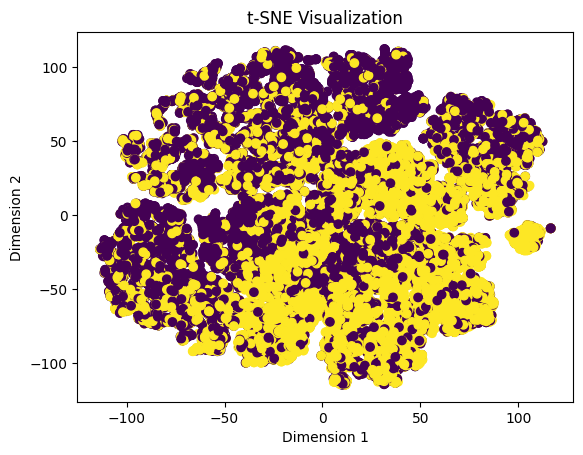

In [19]:
#tsne
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


# Assuming X is your preprocessed feature matrix (scaled, normalized, etc.)
# You can also select a subset of features if needed
data4=data3.copy(deep=True)
X=data4.iloc[:,:-1]
y=data4.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
ct = ColumnTransformer([('x', StandardScaler(),[0,2,3,4,5,11,12])], remainder ='passthrough')
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)
# Create a t-SNE model with the desired number of components (e.g., 2 for 2D visualization)
def tsne_vis(X,y):
    tsne = TSNE(n_components=2, random_state=42)

    # Fit and transform your data to the lower-dimensional space
    X_tsne = tsne.fit_transform(X)

    # Now, X_tsne contains the lower-dimensional representation of your data

    # Visualize the t-SNE results (scatter plot)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)  # Assuming 'y' is your target variable for coloring points
    plt.title("t-SNE Visualization")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

In [5]:

from sklearn.naive_bayes import GaussianNB
import sklearn.metrics as metrics

#naive bayes on original data
# X=data3.iloc[:,:-1]
# y=data3.iloc[:,-1]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
# ct = ColumnTransformer([('x', StandardScaler(),[0,1,2,3,4,5,])], remainder ='passthrough')
# X_train = ct.fit_transform(X_train)
# X_test = ct.transform(X_test)
# Assuming X is your feature matrix and y is the target variable (cardio)


def naive_bayes(X_train,X_test,y_train,y_test):


# Create and train the Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = gnb.predict(X_test)
    y_pred_train = gnb.predict(X_train)

    accuracy = metrics.accuracy_score(y_train, y_pred_train)
    recall = metrics.recall_score(y_train,y_pred_train)
    f1 = metrics.f1_score(y_train,y_pred_train)
    precision = metrics.precision_score(y_train,y_pred_train)

    print("Accuracy:", accuracy)
    print("Recall:", recall)
    print("f1:", f1)
    print("Precision:", precision)
    print()
    # Evaluate the model
    accuracy = metrics.accuracy_score(y_test, y_pred)
    recall = metrics.recall_score(y_test,y_pred)
    f1 = metrics.f1_score(y_test,y_pred)
    precision = metrics.precision_score(y_test,y_pred)

    print("Accuracy:", accuracy)
    print("Recall:", recall)
    print("f1:", f1)
    print("Precision:", precision)




    # Print a classification report for more detailed metrics
    print(metrics.classification_report(y_test, y_pred))

ValueError: all features must be in [0, 1] or [-2, 0]

In [ ]:
from sklearn.naive_bayes import GaussianNB
import sklearn.metrics as metrics


# Assuming X is your feature matrix and y is the target variable (cardio)

#naive bayes on one hot encoded data
X=data2.iloc[:,:-1]
y=data2.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
ct = ColumnTransformer([('x', StandardScaler(),[0,1,2,3,4,5,])], remainder ='passthrough')
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

# Create and train the Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gnb.predict(X_test)
y_pred_train = gnb.predict(X_train)

accuracy = metrics.accuracy_score(y_train, y_pred_train)
recall = metrics.recall_score(y_train,y_pred_train)
f1 = metrics.f1_score(y_train,y_pred_train)
precision = metrics.precision_score(y_train,y_pred_train)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("f1:", f1)
print("Precision:", precision)
print()
# Evaluate the model
accuracy = metrics.accuracy_score(y_test, y_pred)
recall = metrics.recall_score(y_test,y_pred)
f1 = metrics.f1_score(y_test,y_pred)
precision = metrics.precision_score(y_test,y_pred)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("f1:", f1)
print("Precision:", precision)




# Print a classification report for more detailed metrics
print(metrics.classification_report(y_test, y_pred))

In [ ]:
from sklearn.naive_bayes import GaussianNB
import sklearn.metrics as metrics


# Assuming X is your feature matrix and y is the target variable (cardio)

#naive bayes on original data with pca
X=data3.iloc[:,:-1]
y=data3.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
ct = ColumnTransformer([('x', StandardScaler(),[0,1,2,3,4,5,])], remainder ='passthrough')
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

# Create and train the Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gnb.predict(X_test)
y_pred_train = gnb.predict(X_train)

accuracy = metrics.accuracy_score(y_train, y_pred_train)
recall = metrics.recall_score(y_train,y_pred_train)
f1 = metrics.f1_score(y_train,y_pred_train)
precision = metrics.precision_score(y_train,y_pred_train)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("f1:", f1)
print("Precision:", precision)
print()
# Evaluate the model
accuracy = metrics.accuracy_score(y_test, y_pred)
recall = metrics.recall_score(y_test,y_pred)
f1 = metrics.f1_score(y_test,y_pred)
precision = metrics.precision_score(y_test,y_pred)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("f1:", f1)
print("Precision:", precision)




# Print a classification report for more detailed metrics
print(metrics.classification_report(y_test, y_pred))

In [ ]:
from sklearn.naive_bayes import GaussianNB
import sklearn.metrics as metrics


# Assuming X is your feature matrix and y is the target variable (cardio)

#naive bayes on one hot encoded data with pca
X=data3.iloc[:,:-1]
y=data3.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
ct = ColumnTransformer([('x', StandardScaler(),[0,1,2,3,4,5,])], remainder ='passthrough')
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

# Create and train the Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gnb.predict(X_test)
y_pred_train = gnb.predict(X_train)

accuracy = metrics.accuracy_score(y_train, y_pred_train)
recall = metrics.recall_score(y_train,y_pred_train)
f1 = metrics.f1_score(y_train,y_pred_train)
precision = metrics.precision_score(y_train,y_pred_train)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("f1:", f1)
print("Precision:", precision)
print()
# Evaluate the model
accuracy = metrics.accuracy_score(y_test, y_pred)
recall = metrics.recall_score(y_test,y_pred)
f1 = metrics.f1_score(y_test,y_pred)
precision = metrics.precision_score(y_test,y_pred)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("f1:", f1)
print("Precision:", precision)




# Print a classification report for more detailed metrics
print(metrics.classification_report(y_test, y_pred))